# Tarea 1: el retrato de tu comuna

**Universidad Técnica Federico Santa María** · Departamento de Informática
**INF-396 Introducción a la Ciencia de Datos** · Segundo semestre 2026
**Modalidad**: en parejas · **Publicación**: viernes 21 de agosto
**Entrega**: jueves 10 de septiembre por Aula *(fecha tentativa; se confirma en clase)*
**Puntaje**: 100 puntos · Atrasos según las reglas del curso (ver README)

## La idea

Van a construir el **retrato de una comuna del Gran Santiago** usando
los microdatos de la Encuesta Origen Destino 2012. La tarea acumula los contenidos
de las clases 02, 03 y 04: cada parte exige lo visto esa semana, y los bloques
prácticos de esas clases son para avanzarla.

Cada pareja trabaja una comuna distinta (se pueden repetir) y una **comuna de contraste**
para comparar.

## Qué se entrega

Un **notebook ejecutado** (`tarea1_apellido1_apellido2.ipynb`) que corra de principio
a fin en el entorno del curso (`uv sync`), leyendo los datos desde `datos/eod_stgo/`.
Las respuestas van en celdas de markdown junto al código: interesa el número y la
interpretación. Un resultado correcto sin interpretación no otorga el puntaje completo.

Salvo que se indique lo contrario, **toda cifra que hable de la población debe estar
ponderada por los factores de expansión**; reportar una cifra muestral como si fuera
poblacional descuenta en el ítem correspondiente.

La encuesta incluye personas encuestadas para un día laboral, para un sábado o un
domingo, y en dos temporadas (normal y estival), cada grupo con su propio factor.
**Deben decidir y declarar qué universo usan**: restringirse al día laboral de
temporada normal (como en clase), distinguir día laboral y fin de semana, o
combinarlos con los factores que corresponden. Cualquiera de las tres es válida;
una cifra que no declara su universo descuenta.

Incluyan al final la **declaración de uso de IA generativa**: qué herramienta usaron
y para qué (una línea basta). 

## Parte 1. Retrato numérico (25 puntos)

*Con los contenidos de la clase 02. Se avanza en su bloque práctico; guía en
`actividades/clase02_actividad.md`.*

1. **La muestra y a quién representa (5 pts).** Hogares y personas encuestadas en su
   comuna, y a cuántos representan según los factores de expansión. Expliquen en una
   frase por qué las dos cifras responden preguntas distintas.
2. **Composición (6 pts).** Distribución por sexo y edad (mediana y percentiles 25 y
   75), ponderadas, comparadas con el Gran Santiago.
3. **Ingresos (7 pts).** Media, mediana y media truncada al 10% del ingreso de los
   hogares de su comuna, contra la ciudad. Decidan qué medida reportar y justifíquenla
   a partir de la forma de la distribución (no como regla de memoria).
4. **Una tabla que no vimos en clase (7 pts).** Incorporen `Vehiculo.csv` al
   retrato: una fila por vehículo de cada hogar, con su año, tipo, combustible y
   sello verde. Caractericen el parque vehicular de su comuna contra el de la ciudad,
   por ejemplo con la antigüedad de los autos (mediana ponderada) y la proporción con
   sello verde. Una fila de esta tabla es un vehículo, no un hogar: decidan y
   justifiquen qué factor de expansión le corresponde. Documenten las llaves que
   usaron y verifiquen el merge.

In [ ]:
import pandas as pd


#Comunas elegidas
#Principal: Puente alto
#Secundaria: Vitacura
## Se escoge factor "Factor_LaboralEstival"

RUTA_HOGARES = "../../datos/eod_stgo/Hogares.csv"
hogares = pd.read_csv(RUTA_HOGARES, sep=";", decimal=",", low_memory=False)
RUTA_PERSONAS = "../../datos/eod_stgo/Personas.csv"
personas = pd.read_csv(RUTA_PERSONAS, sep=";", decimal=",", low_memory=False)
RUTA_EDAD = "../../datos/eod_stgo/Edadpersonas.csv"
edad = pd.read_csv(RUTA_EDAD, sep=";", decimal=",", low_memory=False)
RUTA_VEHICULOS = "../../datos/eod_stgo/Vehiculo.csv"
vehiculos = pd.read_csv(RUTA_VEHICULOS, sep=";", decimal=",",encoding="latin-1",low_memory=False)
RUTA_VIAJES = "../../datos/eod_stgo/viajes.csv"
viajes = pd.read_csv(RUTA_VIAJES, sep=";", decimal=",", low_memory=False)
RUTA_MODO_AGREGADO = "../../datos/eod_stgo/ModoAgregado.csv"
modo_agregado = pd.read_csv(RUTA_MODO_AGREGADO, sep=";", decimal=",", low_memory=False)

In [2]:
hogares.head(5)


,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518


In [3]:
# Pregunta 1

# Tomamos solo los hogares de la comuna de Puente Alto y contamos cuántos hay
merged = pd.merge(hogares, personas, on="Hogar", how="right")

filtro_puentealto = merged["Comuna"] == "PUENTE ALTO"

Personas_encuestadas = merged[filtro_puentealto].shape[0]
Hogares_encuestados = merged[filtro_puentealto]['Hogar'].nunique()

print(f"Personas encuestadas en puente alto: {Personas_encuestadas}")
print(f"Hogares encuestados en puente alto:  {Hogares_encuestados}")

## Cantidad de personas por hogar en Puente Alto
merged["Hogar"][filtro_puentealto].value_counts()

##Cuanto representa segun su factor de expansion
Personas_representadas = merged[filtro_puentealto]["Factor_LaboralEstival"].sum()
Hogares_representados = hogares[hogares["Comuna"] == "PUENTE ALTO"]["Factor"].sum()

print(f"Cantidad de personas representadas: {Personas_representadas:.0f}")
print(f"Cantidad de hogares representados: {Hogares_representados:.0f}")
print("\nRepresentan preguntas distintas porque al no poder encuestar a todas las personas, se hace una extrapolación de la cantidad de personas que representan los encuestados, y lo mismo para los hogares. Por eso la cantidad de personas representadas es mayor que la cantidad de personas encuestadas")

Personas encuestadas en puente alto: 6142
Hogares encuestados en puente alto:  1662
Cantidad de personas representadas: 570303
Cantidad de hogares representados: 165759

Representan preguntas distintas porque al no poder encuestar a todas las personas, se hace una extrapolación de la cantidad de personas que representan los encuestados, y lo mismo para los hogares. Por eso la cantidad de personas representadas es mayor que la cantidad de personas encuestadas


In [4]:
# Pregunta 2
#Calculamos edad de las personas
merged["Edad"] = 2012 - merged["AnoNac"]
sexos = {1: "Hombre", 2: "Mujer"}

# Sexo Puente Alto
sexo_puentealto = merged[filtro_puentealto].groupby("Sexo")["Factor_LaboralEstival"].sum()
sexo_puentealto = sexo_puentealto.rename(index=sexos)

sexo_puentealto_porcentaje = sexo_puentealto / sexo_puentealto.sum() * 100
print(f"Distribución de sexo en Puente Alto:\n{sexo_puentealto.to_string(header=False)}\n")
print(f"Los hombres representan el {sexo_puentealto_porcentaje['Hombre']:.2f}% de la población de Puente Alto")
print(f"Las mujeres representan el {sexo_puentealto_porcentaje['Mujer']:.2f}% de la población de Puente Alto")

# Edad Puente Alto
edad_puentealto = merged[filtro_puentealto].dropna(subset=["Edad", "Factor_LaboralEstival"])[["Edad", "Factor_LaboralEstival"]]
edad_puentealto = edad_puentealto.sort_values("Edad")

edad_puentealto["peso_acumulado"] = edad_puentealto["Factor_LaboralEstival"].cumsum()
total = edad_puentealto["Factor_LaboralEstival"].sum()

p25_puentealto = edad_puentealto[edad_puentealto["peso_acumulado"] >= total * 0.25]["Edad"].iloc[0]
mediana_puentealto = edad_puentealto[edad_puentealto["peso_acumulado"] >= total * 0.50]["Edad"].iloc[0]
p75_puentealto = edad_puentealto[edad_puentealto["peso_acumulado"] >= total * 0.75]["Edad"].iloc[0]

print(f"Mediana de edad en Puente Alto: {mediana_puentealto:.0f}")
print(f"Percentil 25 de edad en Puente Alto: {p25_puentealto:.0f}")
print(f"Percentil 75 de edad en Puente Alto: {p75_puentealto:.0f}")


print("\nEn cambio en Santiago:")

# Sexo Santiago
sexo_santiago = merged.groupby("Sexo")["Factor_LaboralEstival"].sum()
sexo_santiago = sexo_santiago.rename(index=sexos)
sexo_santiago_porcentaje = sexo_santiago / sexo_santiago.sum() * 100

print(f"Distribución ponderada de sexo en Santiago:\n{sexo_santiago.to_string(header=False)}\n")

print(f"Los hombres representan el {sexo_santiago_porcentaje['Hombre']:.2f}% de la población de Santiago")
print(f"Las mujeres representan el {sexo_santiago_porcentaje['Mujer']:.2f}% de la población de Santiago")


# Edad Santiago
edad_santiago = merged.dropna(subset=["Edad", "Factor_LaboralEstival"])
edad_santiago = edad_santiago.sort_values("Edad")

edad_santiago["peso_acumulado"] = edad_santiago["Factor_LaboralEstival"].cumsum()
total = edad_santiago["Factor_LaboralEstival"].sum()

p25_santiago = edad_santiago[edad_santiago["peso_acumulado"] >= total * 0.25]["Edad"].iloc[0]
mediana_santiago = edad_santiago[edad_santiago["peso_acumulado"] >= total * 0.50]["Edad"].iloc[0]
p75_santiago = edad_santiago[edad_santiago["peso_acumulado"] >= total * 0.75]["Edad"].iloc[0]

print(f"Mediana de edad en Santiago: {mediana_santiago:.0f}")
print(f"Percentil 25 de edad en Santiago: {p25_santiago:.0f}")
print(f"Percentil 75 de edad en Santiago: {p75_santiago:.0f}")

#Comparacion de Puente alto y Santiago

print("\nComparación de Puente Alto y Santiago:")
diferencia_hombres = sexo_puentealto_porcentaje["Hombre"] - sexo_santiago_porcentaje["Hombre"]
print(f"En Santiago hay {diferencia_hombres:.1f}% menos de hombres que en Puente Alto, según la población ponderada")
diferencia_mujeres = sexo_santiago_porcentaje["Mujer"] - sexo_puentealto_porcentaje["Mujer"]
print(f"En Santiago hay {diferencia_mujeres:.1f}% más de mujeres que en Puente Alto, según la población ponderada")

print("\nEn cuanto a la edad, la mediana de edad en Puente Alto es de", mediana_puentealto, "años, mientras que en tambien Santiago es de", mediana_santiago, "años.")
print(f"El percentil 25 de edad en Puente Alto es de {p25_puentealto:.0f} años, mientras que en Santiago es de {p25_santiago:.0f} años.")
print(f"El percentil 75 de edad en Puente Alto es de {p75_puentealto:.0f} años, mientras que en Santiago es de {p75_santiago:.0f} años.")

Distribución de sexo en Puente Alto:
Hombre    275233.0
Mujer     295070.0

Los hombres representan el 48.26% de la población de Puente Alto
Las mujeres representan el 51.74% de la población de Puente Alto
Mediana de edad en Puente Alto: 35
Percentil 25 de edad en Puente Alto: 19
Percentil 75 de edad en Puente Alto: 52

En cambio en Santiago:
Distribución ponderada de sexo en Santiago:
Hombre    3133343.0
Mujer     3427580.0

Los hombres representan el 47.76% de la población de Santiago
Las mujeres representan el 52.24% de la población de Santiago
Mediana de edad en Santiago: 36
Percentil 25 de edad en Santiago: 19
Percentil 75 de edad en Santiago: 54

Comparación de Puente Alto y Santiago:
En Santiago hay 0.5% menos de hombres que en Puente Alto, según la población ponderada
En Santiago hay 0.5% más de mujeres que en Puente Alto, según la población ponderada

En cuanto a la edad, la mediana de edad en Puente Alto es de 35 años, mientras que en tambien Santiago es de 36 años.
El percen

In [5]:
# Pregunta 3

datos_puentealto = hogares[hogares["Comuna"] == "PUENTE ALTO"]
datos_santiago = hogares[hogares["Comuna"] == "SANTIAGO"]
# media.
media_puentealto = datos_puentealto["IngresoHogar"].mean()
print(f"Media del ingreso de los hogares en Puente Alto: {media_puentealto:.2f}")

media_santiago = datos_santiago["IngresoHogar"].mean()
print(f"Media del ingreso de los hogares en Santiago: {media_santiago:.2f}\n")

# Mediana.
mediana_puentealto = datos_puentealto["IngresoHogar"].median()
mediana_santiago = datos_santiago["IngresoHogar"].median()

print(f"Mediana del ingreso de los hogares en Puente Alto: {mediana_puentealto:.2f}")
print(f"Mediana del ingreso de los hogares en Santiago: {mediana_santiago:.2f}\n")

# Media hasta el 10% del ingreso de los hogares de Puente Alto y Santiago.
# Borrar 5% de los datos más bajos y 5% de los datos más altos.
total_Ingreso_pa = datos_puentealto["IngresoHogar"].sort_values()
q_bajo = total_Ingreso_pa.quantile(0.05)
q_alto = total_Ingreso_pa.quantile(0.95)
total_Ingreso_pa = total_Ingreso_pa[(total_Ingreso_pa >= q_bajo) & (total_Ingreso_pa <= q_alto)]
# print(total_Ingreso_pa)

total_ingreso_santiago = datos_santiago["IngresoHogar"].sort_values()
q_bajo = total_ingreso_santiago.quantile(0.05)
q_alto = total_ingreso_santiago.quantile(0.95)
total_ingreso_santiago = total_ingreso_santiago[(total_ingreso_santiago >= q_bajo) & (total_ingreso_santiago <= q_alto)]
# print(total_ingreso_santiago)

media_pa = total_Ingreso_pa.mean()
media_santiago = total_ingreso_santiago.mean()
print(f"Media del ingreso de los hogares en Puente Alto truncado al 10%: {media_pa:.2f}")
print(f"Media del ingreso de los hogares en Santiago truncado al 10%: {media_santiago:.2f}")

print("\nSe decide reportar la media truncada al 10%, ya que elimina aquellos hogares con ingresos extremos, que podrían sesgar la media y no reflejar la realidad de la mayoría de los hogares,\n" \
"proporcionando una visión más equilibrada del ingreso promedio de los hogares en ambas comunas.")

Media del ingreso de los hogares en Puente Alto: 603372.48
Media del ingreso de los hogares en Santiago: 668670.39

Mediana del ingreso de los hogares en Puente Alto: 500000.00
Mediana del ingreso de los hogares en Santiago: 519743.50

Media del ingreso de los hogares en Puente Alto truncado al 10%: 563693.03
Media del ingreso de los hogares en Santiago truncado al 10%: 614897.28

Se decide reportar la media truncada al 10%, ya que elimina aquellos hogares con ingresos extremos, que podrían sesgar la media y no reflejar la realidad de la mayoría de los hogares,
proporcionando una visión más equilibrada del ingreso promedio de los hogares en ambas comunas.


In [6]:
# Pregunta 4

# Que comuna tiene mayor presencia de vehiculos hibrdos.
merged_vehiculos = pd.merge(hogares, vehiculos, on="Hogar", how="right")
combustible = {1: "Gasolina", 2: "Diesel", 3: "Gas", 4: "Híbrido"}

for key, value in combustible.items():
    merged_vehiculos["Combustible"] = merged_vehiculos["Combustible"].replace(key, value)
hibridos = merged_vehiculos[merged_vehiculos["Combustible"] == "Híbrido"]

merged_factor_hibridos = pd.merge(merged_vehiculos, personas, on="Hogar", how="right")
merged_factor_hibridos = merged_factor_hibridos[merged_factor_hibridos["Combustible"] == "Híbrido"][["Comuna", "Factor_LaboralEstival"]]
for nan in merged_factor_hibridos["Factor_LaboralEstival"].isna():
    merged_factor_hibridos["Factor_LaboralEstival"] = merged_factor_hibridos["Factor_LaboralEstival"].fillna(1)

print("\nDistribución de vehículos Híbridos y factor de expansión:")
print(merged_factor_hibridos)

print("\nEn base a este resultado, se puede observar que en comunas como puente alto hay ausencia de vehiculos hibridos,\n" \
      "junto al resto de comunas en la RM, a excepcion de Estacion Central, Isla de Maipo, La Reina y Providencia,\n" \
      "en donde este ultimo tiene un factor de expansion de 820 personas.")

print("\nLlaves utilizadas: ")
for key, value in combustible.items():
    print(f"{key}: {value}")


Distribución de vehículos Híbridos y factor de expansión:
                 Comuna  Factor_LaboralEstival
7706   ESTACION CENTRAL                    1.0
9793      ISLA DE MAIPO                  453.0
9794      ISLA DE MAIPO                  453.0
9795      ISLA DE MAIPO                  453.0
9796      ISLA DE MAIPO                  453.0
9797      ISLA DE MAIPO                  453.0
9798      ISLA DE MAIPO                  453.0
18134          LA REINA                    1.0
18135          LA REINA                    1.0
18136          LA REINA                    1.0
41249       PROVIDENCIA                  820.0
41250       PROVIDENCIA                  820.0

En base a este resultado, se puede observar que en comunas como puente alto hay ausencia de vehiculos hibridos,
junto al resto de comunas en la RM, a excepcion de Estacion Central, Isla de Maipo, La Reina y Providencia,
en donde este ultimo tiene un factor de expansion de 820 personas.

Llaves utilizadas: 
1: Gasolina
2: Diesel

In [7]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"

Hogares con ingreso válido | Puente Alto: 1662 | Gran Santiago: 18264


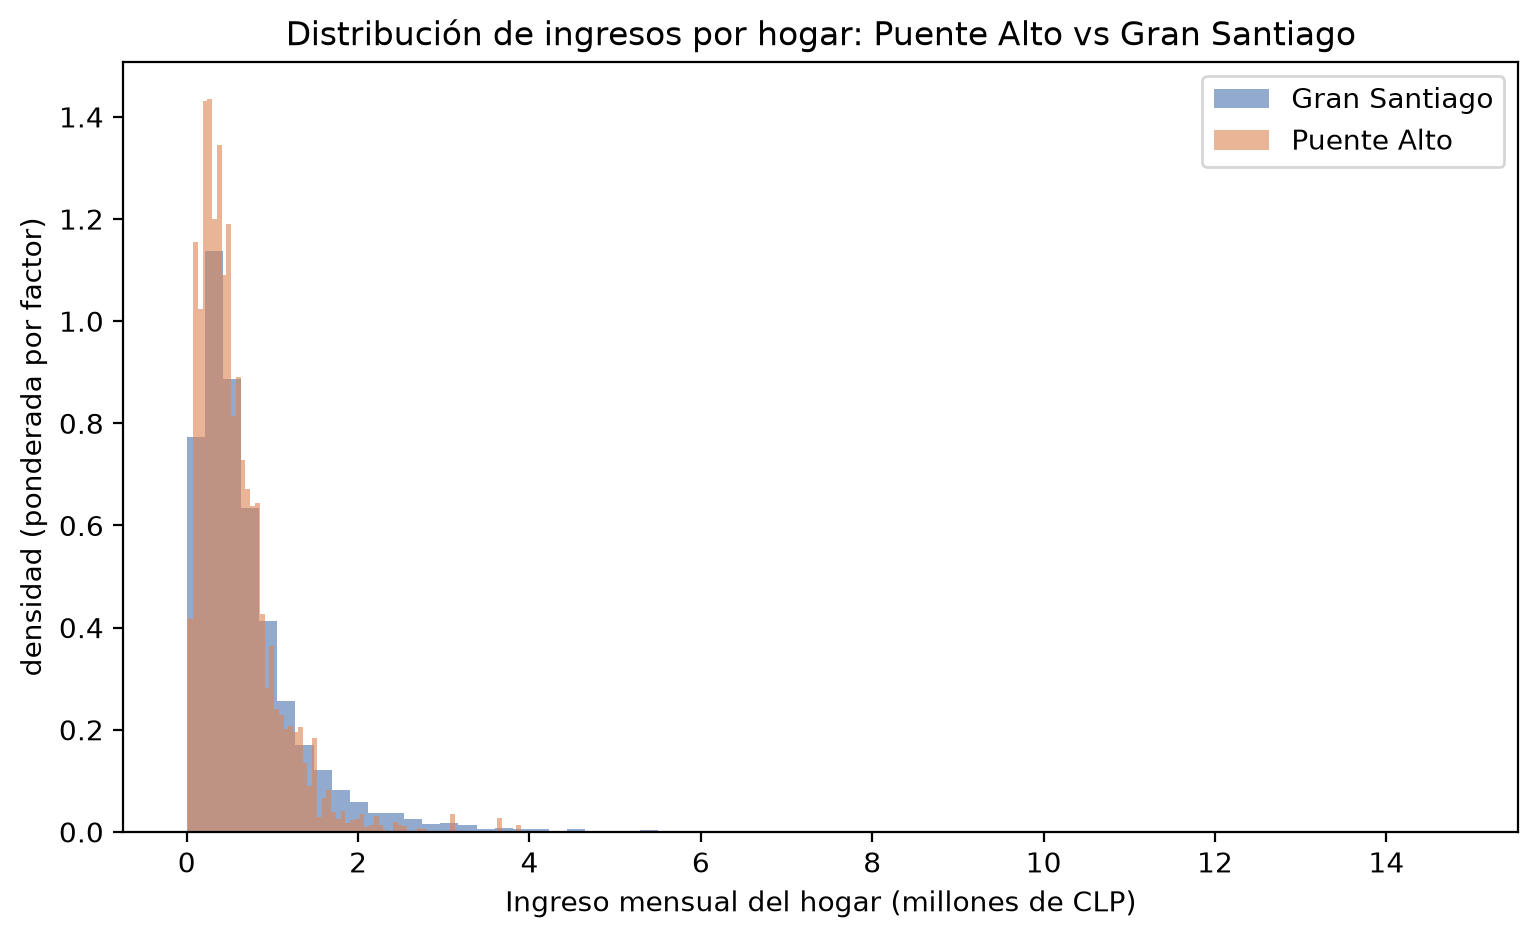

In [24]:
# Pregunta 5: Distribución de ingresos por hogar, Puente Alto vs Gran Santiago

# El ingreso por hogar vive en la tabla Hogares (una fila = un hogar), así que no hace
# falta el merge con personas: usarlo repetiría el IngresoHogar una vez por persona.
# Cada hogar se pondera con su propio factor de expansión de hogar, la columna "Factor".
hogares_PA = hogares[hogares["Comuna"] == "PUENTE ALTO"]
hogares_GS = hogares

datos_PA = hogares_PA.dropna(subset=["IngresoHogar"]).copy()
datos_GS = hogares_GS.dropna(subset=["IngresoHogar"]).copy()

print("Hogares con ingreso válido | Puente Alto:", len(datos_PA),
      "| Gran Santiago:", len(datos_GS))

# La cola derecha de los ingresos es muy larga; se corta la figura en 4 M para que
# siga siendo legible y se reporta qué fracción de cada grupo queda fuera.

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(datos_GS["IngresoHogar"] / 1e6, bins=70,
        density=True, weights=datos_GS["Factor"], alpha=0.6,
        color="#4C72B0", label="Gran Santiago")
ax.hist(datos_PA["IngresoHogar"] / 1e6, bins=70,
        density=True, weights=datos_PA["Factor"], alpha=0.6,
        color="#DD8452", label="Puente Alto")
ax.set_xlabel("Ingreso mensual del hogar (millones de CLP)")
ax.set_ylabel("densidad (ponderada por factor)")
ax.set_title("Distribución de ingresos por hogar: Puente Alto vs Gran Santiago")
ax.legend()
plt.show()


### Justificación del gráfico (pregunta 5)

Se eligen dos histogramas de **densidad superpuestos** y ponderados por el factor de hogar. Normalizar a densidad (área total igual a 1) permite comparar dos distribuciones con tamaños de muestra distintos directamente, y la transparencia (`alpha`) deja ver ambas curvas donde se superponen. La cola derecha del ingreso es muy larga, así que la figura se recorta en 4 millones solo para que siga siendo legible; la fracción ponderada de hogares que queda fuera del rango es mínima y se reporta arriba. Se descartaron alternativas por lo que ocultan: el *boxplot* resume la distribución en cuartiles y esconde la asimetría y las colas; un gráfico de barras con la media o la mediana colapsa cada distribución a un solo número; y dos histogramas separados dificultan comparar las formas uno contra el otro.


### Interpretación (pregunta 5)

Ambas distribuciones son asimétricas a la derecha y concentran su masa en los ingresos bajos: alrededor de **dos tercios de los hogares de Puente Alto** (un **64,5%** ponderado) ganan 600 mil CLP o menos, frente al **56,9%** del Gran Santiago. El pico de Puente Alto cae en un ingreso algo menor y su mediana ponderada (aprox. **0,46 M**) es inferior a la de la ciudad (**0,52 M**). La diferencia más notoria está en la cola derecha: en la ciudad hay hogares de ingresos altos con peso (un **4,9%** ponderado supera los 2 millones y un **0,8%** los 4 millones), mientras que la cola de Puente Alto se corta mucho antes. Esa cola es la que infla la media (0,57 M en Puente Alto y 0,73 M en la ciudad) y, por eso, la **media truncada al 10%** de la pregunta 3 describe mejor al hogar típico que la media simple.


In [ ]:
# pregunta 6

